# **I. Classification**
* **Definition:** A supervised machine learning method that uses trained models to predict discrete, categorical labels for new data.
* **Mechanism:** It maps the association between input features and target variables to classify data into predefined categories. 

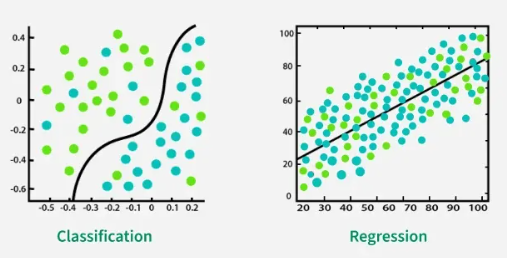

## **1/ Real-World Applications**
* **Business & Marketing:** 
  * **Churn Prediction:** Identifying if a customer is likely to discontinue a service.
  * **Customer Segmentation:** Categorizing customers into specific demographic or behavioral groups.
  * **Ad Responsiveness:** Predicting whether a customer will engage with an advertising campaign.
* **Finance:** Predicting loan defaults (binary classification: default vs. no default) based on applicant age, income, and debt levels.
* **Healthcare:** Recommending specific drug prescriptions (multi-class classification) based on how similar patients responded to treatments.
* **Technology:** Email filtering (spam vs. inbox), speech-to-text, handwriting recognition, and biometric identification.

## **2/ Common Classification Algorithms**
* Naive Bayes
* Logistic Regression
* Decision Trees
* K-Nearest Neighbors (KNN)
* Support Vector Machines (SVM)
* Neural Networks

*(Note: Algorithms like Logistic Regression, KNN, and Decision Trees can natively distinguish multiple classes. Others are strictly binary and require extension strategies to handle multi-class problems.)*

## **3/ Multi-Class Classification Strategies**
Techniques used to extend strictly binary classifiers to handle datasets with more than two target classes.

* **One-Versus-All (OvA) / One-Versus-Rest:**
  * Implements exactly $k$ independent binary classifiers for a dataset with $k$ classes.
  * Each classifier makes a binary prediction for a single label: *"Does it belong to Class A, or everything else?"*
  * **Outlier Detection:** Data points that fail to trigger any of the individual classifiers fall into an "unclassified" bucket, which is highly useful for identifying noise or anomalies.
* **One-Versus-One (OvO):**
  * Evaluates every possible pair of classes.
  * Each classifier focuses strictly on two labels at a time, asking: *"Is it Class A or Class B?"*
  * **Voting Scheme:** The final class prediction is determined by popularity (the class that wins the most binary match-ups). In the event of a tie, the scheme can be improved by weighing votes based on the confidence level/probability of each classifier's prediction.

---

# **II. Decision Trees Overview**
* **Definition:** A supervised machine learning algorithm visualized as a flowchart for classifying data points.
  * **Internal Node:** Represents a test on a specific feature (e.g., "Is cholesterol high?").
  * **Branch:** Represents the outcome or result of the test.
  * **Leaf / Terminal Node:** Assigns the final class label (e.g., "Prescribe Drug A").
* **Key Advantages:** They are highly interpretable (easy to visualize) and automatically reveal feature importance (the most predictive features appear at the top of the tree).


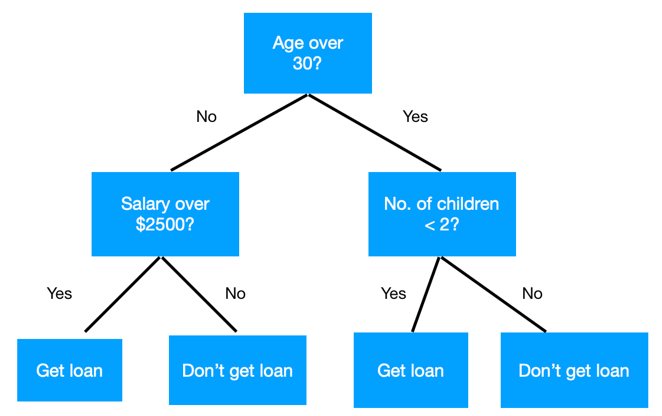

## **1/ Training & Splitting the Data**
* **Recursive Partitioning:** The tree is built by evaluating features one by one, selecting the feature that *best* separates the data into its predefined classes at each node.
* **Splitting Criteria (Measuring Split Quality):**
  * **Entropy:** Measures the disorder, randomness, or uncertainty in a node.
    * `0` = Completely homogenous (pure node, all data belongs to one class).
    * `1` = Completely random (classes are equally divided).
    * *Goal:* The algorithm seeks splits that result in the lowest possible entropy.
  * **Information Gain (Entropy Reduction):** Calculated as the entropy of the tree *before* the split minus the weighted entropy *after* the split. The algorithm prioritizes features that return the highest Information Gain.
  * **Gini Impurity:** Another common metric used alongside Information Gain to evaluate split quality.

## **2/ Pruning & Stopping Criteria**
* **The Overfitting Problem:** If a tree is allowed to grow until every leaf is perfectly pure, it will memorize the training data—including noise and irrelevant details—resulting in a highly complex model that performs poorly on new data.
* **Pruning:** The process of cutting branches that don't significantly improve performance. It simplifies the model, improves generalization, and increases predictive accuracy.
* **Stopping Criteria (Pre-emptive Pruning):** You can force the tree to stop growing when certain thresholds are met:
  * The maximum tree depth is reached.
  * A node contains fewer than the minimum required data points to split.
  * A leaf contains fewer than the minimum required samples.
  * The maximum allowed number of leaf nodes is reached.


---
# **III. Regression Trees vs. Classification Trees**
* **Definition:** A regression tree is analogous to a decision tree but is designed to predict **continuous values** (e.g., salary, temperature, revenue) rather than discrete categorical labels.
* **Leaf Node Predictions:** 
  * *Classification:* Uses a majority vote to assign a discrete class.
  * *Regression:* Uses the **average (mean)** of the target values in that node to make a prediction (or the median if the data is highly skewed).

## **1/Building a Regression Tree**
* **The Splitting Goal:** Unlike classification trees that use Entropy or Information Gain, regression trees recursively split the dataset to **minimize the variance or Mean Squared Error (MSE)** of the target values. This process reduces the spread of the predicted values within each node.
* **Measuring Split Quality:** 
  * The model calculates the MSE for the left and right subsets of a potential split. 
  * It then calculates the **weighted average of the MSEs** for those splits. 
  * The split with the lowest weighted MSE (lowest variance) is chosen as the optimal split.

## **2/Handling Different Feature Types**
* **Binary Features:** The data is separated into its two natural categories, and the split quality is evaluated using the weighted average of their MSEs.
* **Categorical Features with Multiple Levels:** The model evaluates different **binary partitions** of the categories and selects the partition that minimizes the weighted MSE *(Note: Do not use classification strategies like One-Versus-All here)*.
* **Continuous Features:** 
  1. Sort the feature's values and drop duplicates.
  2. Define candidate thresholds ($\alpha_i$) as the midpoints between each pair of consecutive values: $\alpha_i = \frac{X_i + X_{i+1}}{2}$.
  3. Exhaustively test these thresholds to find the one that minimizes the weighted MSE. 
  4. *Optimization:* For massive datasets, sampling a sparse subset of these thresholds based on the data's distribution can improve computational efficiency.

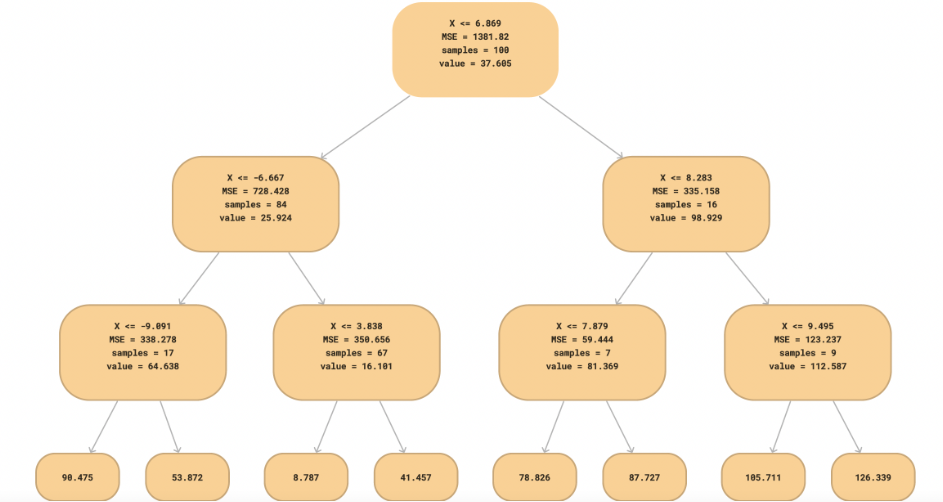

---

# **IV. CHEATSHEET**
## **1/ Classification & Regression Models**

| Process / Model Name | Brief Description | Code Syntax |
| :--- | :--- | :--- |
| **One vs One classifier**<br>*(using logistic regression)* | **Process:** Trains one classifier for each pair of classes.<br><br>**Key hyperparameters:**<br>- `estimator`: Base classifier (e.g., logistic regression)<br><br>**Pros:** Can work well for small datasets.<br>**Cons:** Computationally expensive for large datasets.<br>**Common applications:** Multiclass classification problems where the number of classes is relatively small. | `from sklearn.multiclass import OneVsOneClassifier`<br>`from sklearn.linear_model import LogisticRegression`<br><br>`model = OneVsOneClassifier(LogisticRegression())` |
| **One vs All classifier**<br>*(using logistic regression)* | **Process:** Trains one classifier per class, where each classifier distinguishes between one class and the rest.<br><br>**Key hyperparameters:**<br>- `estimator`: Base classifier (e.g., Logistic Regression)<br>- `multi_class`: Strategy to handle multiclass classification (`ovr`)<br><br>**Pros:** Simpler and more scalable than One vs One.<br>**Cons:** Less accurate for highly imbalanced classes.<br>**Common applications:** Common in multiclass classification problems such as image classification. | `from sklearn.multiclass import OneVsRestClassifier`<br>`from sklearn.linear_model import LogisticRegression`<br><br>`model = OneVsRestClassifier(LogisticRegression())` |
| **Decision tree classifier** | **Process:** A tree-based classifier that splits data into smaller subsets based on feature values.<br><br>**Key hyperparameters:**<br>- `max_depth`: Maximum depth of the tree<br><br>**Pros:** Easy to interpret and visualize.<br>**Cons:** Prone to overfitting if not pruned properly.<br>**Common applications:** Classification tasks, such as credit risk assessment. | `from sklearn.tree import DecisionTreeClassifier`<br><br>`model = DecisionTreeClassifier(max_depth=5)` |
| **Decision tree regressor** | **Process:** Similar to the decision tree classifier, but used for regression tasks to predict continuous values.<br><br>**Key hyperparameters:**<br>- `max_depth`: Maximum depth of the tree<br><br>**Pros:** Easy to interpret, handles nonlinear data.<br>**Cons:** Can overfit and perform poorly on noisy data.<br>**Common applications:** Regression tasks, such as predicting housing prices. | `from sklearn.tree import DecisionTreeRegressor`<br><br>`model = DecisionTreeRegressor(max_depth=5)` |
| **Linear SVM classifier** | **Process:** A linear classifier that finds the optimal hyperplane separating classes with a maximum margin.<br><br>**Key hyperparameters:**<br>- `C`: Regularization parameter<br>- `kernel`: Type of kernel function (`linear`, `poly`, `rbf`, etc.)<br>- `gamma`: Kernel coefficient (only for `rbf`, `poly`, etc.)<br><br>**Pros:** Effective for high-dimensional spaces.<br>**Cons:** Not ideal for nonlinear problems without kernel tricks.<br>**Common applications:** Text classification and image recognition. | `from sklearn.svm import SVC`<br><br>`model = SVC(kernel='linear', C=1.0)` |
| **K-nearest neighbors classifier** | **Process:** Classifies data based on the majority class of its nearest neighbors.<br><br>**Key hyperparameters:**<br>- `n_neighbors`: Number of neighbors to use<br>- `weights`: Weight function used in prediction (`uniform` or `distance`)<br>- `algorithm`: Algorithm used to compute the nearest neighbors (`auto`, `ball_tree`, `kd_tree`, `brute`)<br><br>**Pros:** Simple and effective for small datasets.<br>**Cons:** Computationally expensive as the dataset grows.<br>**Common applications:** Recommendation systems, image recognition. | `from sklearn.neighbors import KNeighborsClassifier`<br><br>`model = KNeighborsClassifier(n_neighbors=5, weights='uniform')` |
| **Random Forest regressor** | **Process:** An ensemble method using multiple decision trees to improve accuracy and reduce overfitting.<br><br>**Key hyperparameters:**<br>- `n_estimators`: Number of trees in the forest<br>- `max_depth`: Maximum depth of each tree<br><br>**Pros:** Less prone to overfitting than individual decision trees.<br>**Cons:** Model complexity increases with the number of trees.<br>**Common applications:** Regression tasks such as predicting sales or stock prices. | `from sklearn.ensemble import RandomForestRegressor`<br><br>`model = RandomForestRegressor(n_estimators=100, max_depth=5)` |
| **XGBoost regressor** | **Process:** A gradient boosting method that builds trees sequentially to correct errors from previous trees.<br><br>**Key hyperparameters:**<br>- `n_estimators`: Number of boosting rounds<br>- `learning_rate`: Step size to improve accuracy<br>- `max_depth`: Maximum depth of each tree<br><br>**Pros:** High accuracy and works well with large datasets.<br>**Cons:** Computationally intensive, complex to tune.<br>**Common applications:** Predictive modeling, especially in Kaggle competitions. | `import xgboost as xgb`<br><br>`model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)` |

<br>

## **2/ Associated Functions & Utilities**

| Method Name | Brief Description | Code Syntax |
| :--- | :--- | :--- |
| `OneHotEncoder` | Transforms categorical features into a one-hot encoded matrix. | `from sklearn.preprocessing import OneHotEncoder`<br><br>`encoder = OneHotEncoder(sparse=False)`<br>`encoded_data = encoder.fit_transform(categorical_data)` |
| `accuracy_score` | Computes the accuracy of a classifier by comparing predicted and true labels. | `from sklearn.metrics import accuracy_score`<br><br>`accuracy = accuracy_score(y_true, y_pred)` |
| `LabelEncoder` | Encodes labels (target variable) into numeric format. | `from sklearn.preprocessing import LabelEncoder`<br><br>`encoder = LabelEncoder()`<br>`encoded_labels = encoder.fit_transform(labels)` |
| `plot_tree` | Plots a decision tree model for visualization. | `from sklearn.tree import plot_tree`<br><br>`plot_tree(model, max_depth=3, filled=True)` |
| `normalize` | Scales each feature to have zero mean and unit variance (standardization). | `from sklearn.preprocessing import normalize`<br><br>`normalized_data = normalize(data, norm='l2')` |
| `compute_sample_weight` | Computes sample weights for imbalanced datasets. | `from sklearn.utils.class_weight import compute_sample_weight`<br><br>`weights = compute_sample_weight(class_weight='balanced', y=y)` |
| `roc_auc_score` | Computes the Area Under the Receiver Operating Characteristic Curve (AUC-ROC) for binary classification models. | `from sklearn.metrics import roc_auc_score`<br><br>`auc = roc_auc_score(y_true, y_score)` |

---

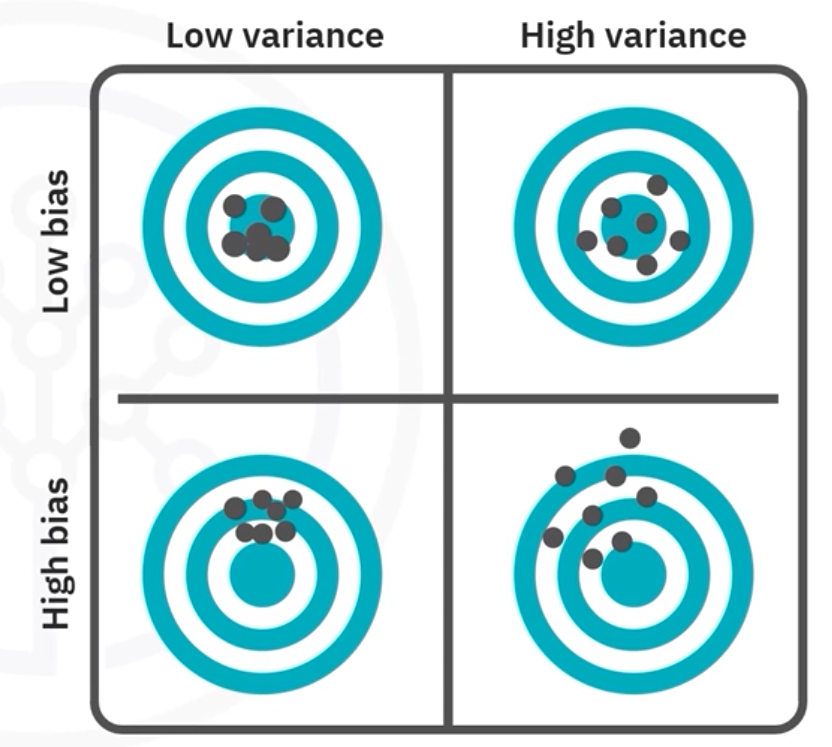
# **V. Bias and Variance**
* **Bias (Accuracy):** Measures how on-target or off-target the model's predictions are compared to actual values.
  * *High Bias:* The model fails to capture the data's underlying trend (underfitting).
  * *Zero Bias:* A perfect predictor.
* **Variance (Precision):** Measures how much predictions fluctuate when the model is trained on different subsets of the dataset.
  * *High Variance:* The model is overly sensitive to noise, outliers, and specific training data (overfitting).
  * *Low Variance:* The model is stable and generalizes well to unseen data.
* **Dartboard Analogy:** 
  * Low Bias = Hitting the center (bullseye).
  * Low Variance = Darts are tightly grouped together.

## **1/ The Bias-Variance Tradeoff**
* **Model Complexity:** 
  * As complexity *increases*, bias *decreases* (fits training data better) but variance *increases* (becomes sensitive to noise).
* **Underfitting (Too Simple):** High bias, low variance. 
* **Overfitting (Too Complex):** Low bias, high variance. 
* **The Goal:** Find the optimal "crossover point" of complexity that balances bias and variance to minimize the overall generalization error.

## **2/ Weak vs. Strong Learners**
* **Weak Learner:** A supervised model that performs only slightly better than random guessing **(High bias, low variance) (underfitting)**
* **Strong Learner:** A complex model that performs extremely well on training data but tends to overfit **(Low bias, high variance) (overfitting)**

## **3/ Ensemble Methods: Bagging vs. Boosting (To balance Bias and Variance)**
Decision and regression trees are commonly used as base learners because their bias and variance can be easily adjusted via tree depth. Ensemble methods combine them to balance the bias-variance tradeoff.

| Feature | Bagging (Bootstrap Aggregating) | Boosting |
| :--- | :--- | :--- |
| **Primary Goal** | Mitigates **overfitting** (Reduces Variance). | Mitigates **underfitting** (Reduces Bias). |
| **Base Learners** | Uses learners with high variance and low bias. | Uses weak learners with high bias and low variance. |
| **Training Execution** | Trains multiple models in **parallel** on randomly sampled (bootstrapped) subsets of data. | Trains models **sequentially**. Each new model specifically focuses on correcting the errors of the previous one. |
| **Mechanism** | Averages the predictions of all models to smooth out variance. | Uses a weighted sum (misclassified data points get higher weights in the next iteration). |
| **Common Algorithms** | Random Forest | Gradient Boosting, XGBoost, AdaBoost |